**Jupyter notebook to carry out linear regression and estimate the best-fit values of the sample. The sample used here is from Gaia DR3 measurement of the Pleiadas cluster**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

First, import the table containing Gaia DR3 data of the Pleiades cluster from Github repository

In [11]:
gaia_url = 'https://raw.githubusercontent.com/NazmaIslam/Observational_Astronomy/refs/heads/main/Pleiades_GaiaDR3.tsv'

gaia_data = pd.read_csv(gaia_url, comment="#", sep=';')
gaia_data

,r(arcsec),RAJ2000(deg),DEJ2000(deg),Plx(mas),e_Plx(mas),PM(mas/yr),Gmag(mag),e_Gmag(mag),BP-RP(mag)
0,0.3721,56.599593,24.107818,1.0024,0.4764,12.013,19.480799,0.004665,0.947384
1,0.5387,56.603180,24.105219,0.8484,0.0825,10.813,16.917551,0.002867,1.638126
2,0.6324,56.593591,24.122231,4.9834,0.0237,23.400,14.331924,0.002771,1.802323
3,0.6510,56.612500,24.111786,0.1464,0.4188,1.115,19.427362,0.004501,1.148716
4,0.6762,56.603619,24.102911,0.9880,0.8817,6.620,20.281404,0.007815,1.799360
...,...,...,...,...,...,...,...,...,...
161,4.9823,56.602245,24.196921,1.1380,0.4095,2.800,19.381740,0.004414,2.138577
162,4.9877,56.681810,24.076000,0.6957,0.1516,15.491,17.904177,0.003192,1.671896
163,4.9901,56.555752,24.041621,0.8164,1.3789,5.681,20.727726,0.011671,0.408096
164,4.9911,56.514579,24.087096,1.1236,0.0639,4.736,16.571363,0.002846,1.491902


Plot the G mag versus BP-RP

Text(0.5, 1.0, 'Gaia Pleiades: Gmag versus BP-RP (Colour Index) Scatter Plot')

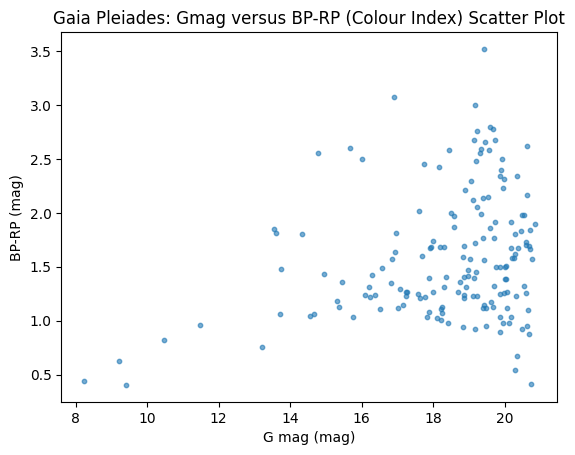

In [12]:
plt.scatter(gaia_data["Gmag(mag)"], gaia_data["BP-RP(mag)"], s=10, alpha=0.6)
plt.xlabel("G mag (mag)")
plt.ylabel("BP-RP (mag)")
plt.title("Gaia Pleiades: Gmag versus BP-RP (Colour Index) Scatter Plot")

**Linear Regression Analysis**

Calculate the Pearson co-efficient or the linear correlation co-efficient. Estimate the best-fit values of the linear equation

In [13]:
result = linregress(gaia_data["Gmag(mag)"], gaia_data["BP-RP(mag)"])

slope = result.slope
intercept = result.intercept
r_value = result.rvalue

print(f"Slope = {slope:.4f}")
print(f"Intercept = {intercept:.4f}")
print(f"Pearson coefficient r = {r_value:.4f}")

Slope = 0.0661
Intercept = 0.3665
Pearson coefficient r = 0.2636


The Pearson co-efficient r is +ve which means Gmag and BP-RP have a linear positive correlation. Plot the best fit linear equation on top of the scatter-plot.

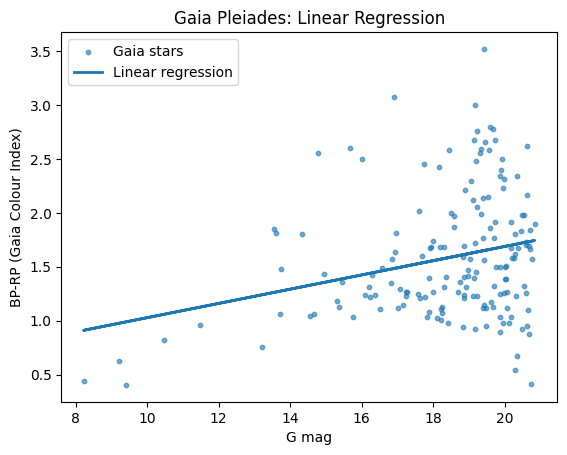

In [14]:
y_fit = intercept + slope * gaia_data["Gmag(mag)"]

plt.scatter(gaia_data["Gmag(mag)"], gaia_data["BP-RP(mag)"], s=10, alpha=0.6, label="Gaia stars")
plt.plot(gaia_data["Gmag(mag)"], y_fit, linewidth=2, label="Linear regression")

plt.xlabel("G mag")
plt.ylabel("BP-RP (Gaia Colour Index)")
plt.title("Gaia Pleiades: Linear Regression")

plt.legend()
plt.show()

Calculate the chi-square statistics of the fit.

In [19]:
gaia_data["Gmag(model)"] = intercept + slope * gaia_data["Gmag(mag)"]


gaia_data["chi2"] = (
    (gaia_data["Gmag(mag)"] - gaia_data["Gmag(model)"])**2
    / gaia_data["e_Gmag(mag)"]**2
)

chi2_total = gaia_data["chi2"].sum()
dof = len(gaia_data["chi2"])
red_chi2 = chi2_total/len(gaia_data["chi2"])

print(f"Total χ² = {chi2_total:.2f}, dof = {dof:.2f}, reduced χ² = {red_chi2:.2f}")

Total χ² = 2827916269.39, dof = 166.00, reduced χ² = 17035640.18
